In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("placement_predict_50k Dataset.csv")

In [ ]:
X = pd.get_dummies(df.drop(columns=["PlacementStatus"]), drop_first=True)
y = df["PlacementStatus"]

X = X.replace([np.inf, -np.inf], np.nan)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
imp = SimpleImputer(strategy="median")
X_train = imp.fit_transform(X_train)
X_val = imp.transform(X_val)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_val = sc.transform(X_val)

In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
results = []

for C in C_values:
    models = {
        "Lasso": LogisticRegression(penalty="l1", C=C, solver="liblinear", max_iter=5000),
        "Ridge": LogisticRegression(penalty="l2", C=C, solver="liblinear", max_iter=5000),
        "ElasticNet": LogisticRegression(penalty="elasticnet", C=C, l1_ratio=.5, solver="saga", max_iter=5000)
    }

    r = {"C": C}

    for name, model in models.items():
        model.fit(X_train, y_train)
        r[name + "_val_acc"] = accuracy_score(y_val, model.predict(X_val))

        if name in ["Lasso", "Ridge"]:
            r[name + "_nonzero"] = np.sum(np.abs(model.coef_) > 1e-6)

    results.append(r)

results_df = pd.DataFrame(results)
results_df

,C,Lasso_val_acc,Lasso_nonzero,Ridge_val_acc,Ridge_nonzero,ElasticNet_val_acc
0,0.001,0.9685,11,0.9461,47,0.9780
1,0.010,0.9971,14,0.9911,47,0.9954
2,0.100,0.9981,23,0.9974,47,0.9976
3,1.000,0.9981,39,0.9981,47,0.9981
4,10.000,0.9982,47,0.9981,47,0.9982
5,100.000,0.9982,47,0.9982,47,0.9982


In [ ]:
print("Best Lasso:\n", results_df.loc[results_df.Lasso_val_acc.idxmax()])
print("\nBest Ridge:\n", results_df.loc[results_df.Ridge_val_acc.idxmax()])
print("\nBest Elastic Net:\n", results_df.loc[results_df.ElasticNet_val_acc.idxmax()])

Best Lasso:
 C                     10.0000
Lasso_val_acc          0.9982
Lasso_nonzero         47.0000
Ridge_val_acc          0.9981
Ridge_nonzero         47.0000
ElasticNet_val_acc     0.9982
Name: 4, dtype: float64

Best Ridge:
 C                     100.0000
Lasso_val_acc           0.9982
Lasso_nonzero          47.0000
Ridge_val_acc           0.9982
Ridge_nonzero          47.0000
ElasticNet_val_acc      0.9982
Name: 5, dtype: float64

Best Elastic Net:
 C                     10.0000
Lasso_val_acc          0.9982
Lasso_nonzero         47.0000
Ridge_val_acc          0.9981
Ridge_nonzero         47.0000
ElasticNet_val_acc     0.9982
Name: 4, dtype: float64


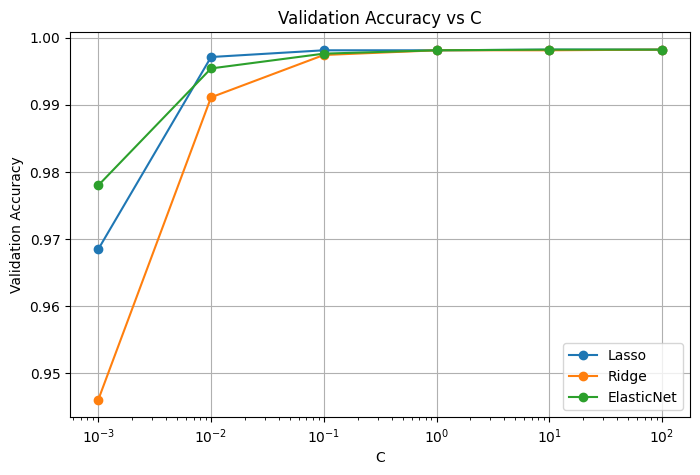

In [ ]:
plt.figure(figsize=(8,5))

for m in ["Lasso", "Ridge", "ElasticNet"]:
    plt.semilogx(C_values, results_df[m+"_val_acc"], marker="o", label=m)

plt.xlabel("C")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs C")
plt.legend()
plt.grid()
plt.show()

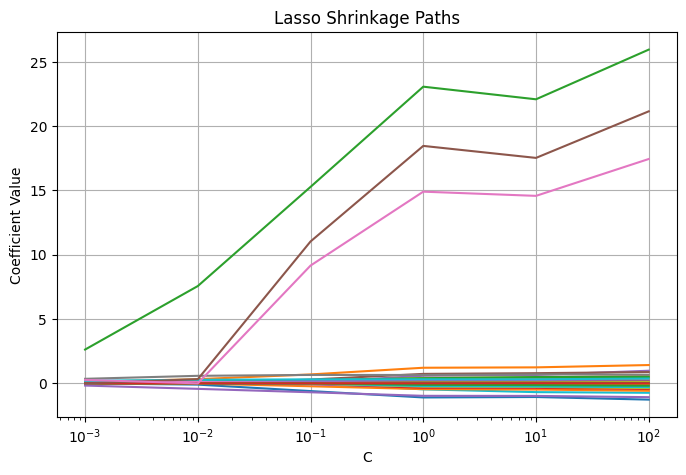

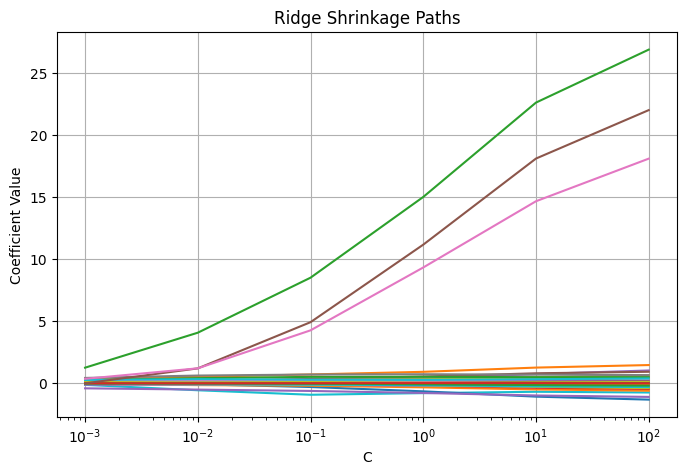

In [ ]:
for penalty, solver, title in [("l1","liblinear","Lasso"), ("l2","liblinear","Ridge")]:
    coefs = []

    for C in C_values:
        model = LogisticRegression(penalty=penalty, C=C, solver=solver, max_iter=5000)
        model.fit(X_train, y_train)
        coefs.append(model.coef_[0])

    plt.figure(figsize=(8,5))
    plt.semilogx(C_values, np.array(coefs))
    plt.xlabel("C")
    plt.ylabel("Coefficient Value")
    plt.title(title + " Shrinkage Paths")
    plt.grid()
    plt.show()